In [1]:
using Plots
using Printf
include("julia_strain_functions.jl")

_log_lorentzian_cost (generic function with 1 method)

# Isolated Level Transition Strain
Below is the envelope for the level transition strain.
When the oscillatory term is added, it only shifts the frequency axis to the transition frequency.
The width of the strain envelope is entirely set by the transition rate.

In [2]:
result = iso_gatom_level_tr_strain(
    M_solar=1e-6,
    a_spin=0.999999,
    alpha=0.75,
    ne=6,
    ng=5,
    distance_kpc=1.0,
    verbose=true,
)

println(keys(result))

f = result["f_pos"]
H = result["H_pos"]
L = result["L_full"]

p = plot(f, abs.(H); xscale=:log10, yscale=:log10,
         label="FFT[h(t)]", xlabel="Frequency [Hz]",
         ylabel="|h~(f)|", title="M_BH = 1e-6, Level Transition (Freq)",
         legend=:topright, size=(1000, 450))
plot!(p, f, L; label="Best-fit Lorentzian", linestyle=:dash)
display(p)

alpha = 0.75
omega_tr = 3.4451407454141036e-16
M = 1.11544991405595e51
gamma_t_ne_GeV = -1.0435340043688468e-80
dist_GeV_inv = 1.5599999999999999e35
alpha = 0.75
ne = 6
ng = 5
mu = 1.0022227623022844e-13
gamma_t_GeV = -1.0435340043688468e-80
Ng = 1.000153240996357
Ne = 1.000168013085263


DomainError: DomainError with -3.341156862686833e-173:
sqrt was called with a negative real argument but will only return a complex result if called with a complex argument. Try sqrt(Complex(x)).

# Associated Time Domain Strain

In [3]:
time_yr = result["time_yr"]
h_t     = result["h_t"]
N_e     = result["N_e"]
N_g     = result["N_g"]

p1 = plot(time_yr, N_e; xscale=:log10, yscale=:log10, label="N_e (excited)",
          xlabel="Time [yr]", ylabel="Population N",
          title="M_BH = 1e-6, Level Transition (time)",
          legend=:topleft, size=(1000, 450))
plot!(p1, time_yr, N_g; label="N_g (ground)")

p2 = plot(time_yr, abs.(h_t); xscale=:log10, yscale=:log10,
          label="|h(t)|", xlabel="Time [yr]", ylabel="Strain |h(t)|",
          legend=:bottomright, size=(1000, 450), linestyle=:dash, color=:black)

display(plot(p1, p2; layout=(2, 1)))

UndefVarError: UndefVarError: `result` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Annihilation Level Transition Strain

alpha ≈ 0.4639687078467587
Annihilation line f_ann ≈ 9.606817781191519e7 Hz
max |h_plus| ≈ 8.210607290037691e-39
max h_c ≈ 1.5908076080724243e-30


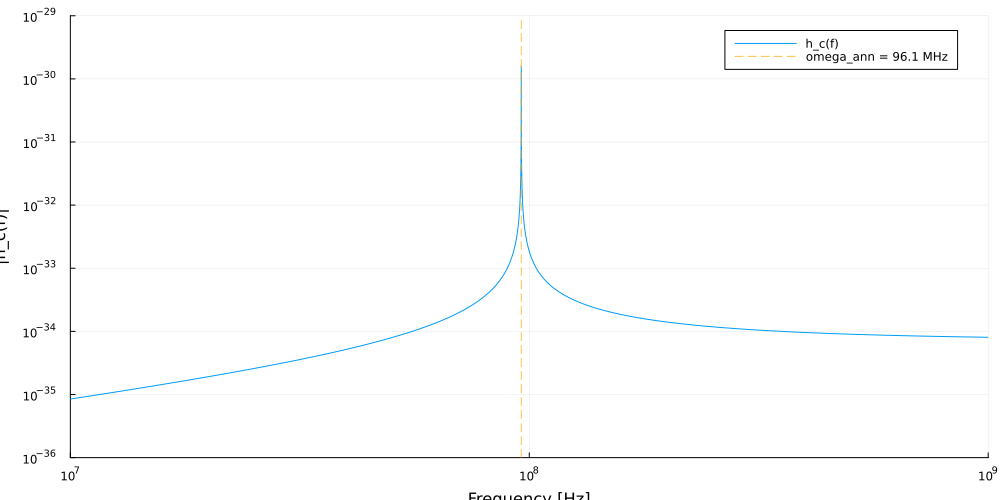

\times10^{-16} GeV, M_BH = 3.10\times10^{-4} M_sun, alpha = 0.46, d = 1.0 kpc: undefined symbol
\times10^{-16} GeV, M_BH = 3.10\times10^{-4} M_sun, alpha = 0.46, d = 1.0 kpc: undefined symbol
\times10^{-16} GeV, M_BH = 3.10\times10^{-4} M_sun, alpha = 0.46, d = 1.0 kpc: undefined symbol
\times10^{-16} GeV, M_BH = 3.10\times10^{-4} M_sun, alpha = 0.46, d = 1.0 kpc: undefined symbol
\times10^{-16} GeV, M_BH = 3.10\times10^{-4} M_sun, alpha = 0.46, d = 1.0 kpc: undefined symbol
\times10^{-16} GeV, M_BH = 3.10\times10^{-4} M_sun, alpha = 0.46, d = 1.0 kpc: undefined symbol
\times10^{-16} GeV, M_BH = 3.10\times10^{-4} M_sun, alpha = 0.46, d = 1.0 kpc: undefined symbol
\times10^{-16} GeV, M_BH = 3.10\times10^{-4} M_sun, alpha = 0.46, d = 1.0 kpc: undefined symbol
\times10^{-16} GeV, M_BH = 3.10\times10^{-4} M_sun, alpha = 0.46, d = 1.0 kpc: undefined symbol
\times10^{-16} GeV, M_BH = 3.10\times10^{-4} M_sun, alpha = 0.46, d = 1.0 kpc: undefined symbol


In [4]:
sci_latex(x; precision=2) = x == 0 ? "0" : begin
    exponent = floor(Int, log10(abs(x)))
    mantissa = x / 10.0^exponent
    @sprintf("%.*f\\times10^{%d}", precision, mantissa, exponent)
end

title_fs  = 20
label_fs  = 20
tick_fs   = 18
legend_fs = 15

M_solar_ann  = 3.1e-4
mua_ann      = 2e-16
distance_kpc = 1.0
n_ann        = 4
iota_ann     = 0.0
phase_ann    = 0.0

f_min = 1e0
f_max = 1e12
N_f   = 50000

res_ann = iso_gatom_ann_strain(
    M_solar=M_solar_ann,
    mua=mua_ann,
    n=n_ann,
    l=nothing,
    alpha=nothing,
    distance_kpc=distance_kpc,
    iota=iota_ann,
    phase=phase_ann,
    f_min_Hz=f_min,
    f_max_Hz=f_max,
    n_f=N_f,
    verbose=true,
)

f_Hz  = res_ann["f_Hz"]
h_c   = res_ann["h_c"]
f_ann = res_ann["f_line_Hz"]
alpha_ann = res_ann["alpha"]
M_ann = res_ann["M_solar"]
r_kpc = res_ann["distance_kpc"]

p = plot(f_Hz, abs.(h_c); xscale=:log10, yscale=:log10,
         label="h_c(f)", xlabel="Frequency [Hz]", ylabel="|h_c(f)|",
         legend=:topright, size=(1000, 500))
xlims!(p, (1e7, 1e9))
ylims!(p, (1e-36, 1e-29))
title!(p, "mu_a = $(sci_latex(mua_ann)) GeV, M_BH = $(sci_latex(M_ann)) M_sun, alpha = $(round(alpha_ann, digits=2)), d = $(r_kpc) kpc")
vline!(p, [f_ann]; label="omega_ann = $(round(f_ann / 1e6, sigdigits=3)) MHz", linestyle=:dash, color=:orange, alpha=0.7)
display(p)